In [1]:
# Import packages
from pathlib import Path
import XvP_utils as plotting

ANALYSIS_NAME = "Analysis_5"
ctx = plotting.notebook_context(ANALYSIS_NAME)
PROJECT_DIR = ctx.project_dir
SPECIES = ctx.species
INDEX_DIR = ctx.index_dir
ANALYSIS_DIR = Path.cwd()
CUTOFFS = ctx.knee('sampled', ['10x', 'polyT', 'randO', 'parse'])
FULL_GENE_INFO_PATH = Path("gene_data/gene_comparisons.csv")

In [1]:
import celltypist
print(celltypist.__version__)

1.7.1


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc

import XvP_utils as plotting

In [3]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [4]:
# # In case you change the package
# import importlib
# importlib.reload(plotting)

In [5]:
data_10x = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='10x', assay ="10x", data_title='10X Genomics')
data_polyT = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='polyT', assay="parse", data_title="Parse 3'")
data_randO = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='randO', assay="parse", data_title='Parse Random Oligo')
data_parse = plotting.init_processing(analysis_name=ANALYSIS_NAME, project_dir=PROJECT_DIR, data_name='parse', assay="parse", data_title='Parse', modified=True)

raw_datasets = [data_10x, data_polyT, data_randO, data_parse]

# Population Upsampling Estimation

PreSeq output already exists for all datasets.


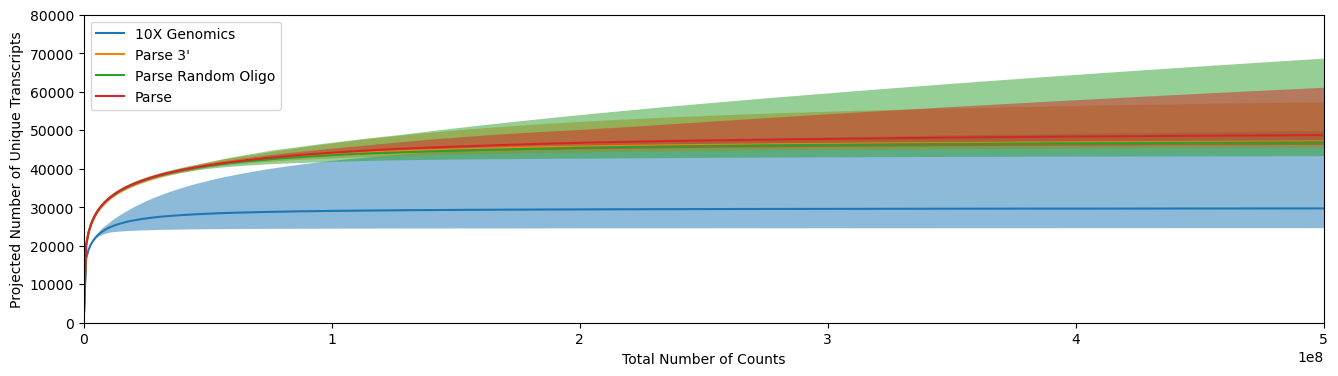

In [6]:
# Launches PreSeq in the background — does not block the notebook.
# Rerun plot_upsample() in a later cell once jobs complete.
plotting.upsample(raw_datasets, Path("preseq"), overwrite=False)
plotting.plot_upsample(raw_datasets, Path("preseq"), xlim=5e8, ylim=8e4)

# Quality Control Comparison

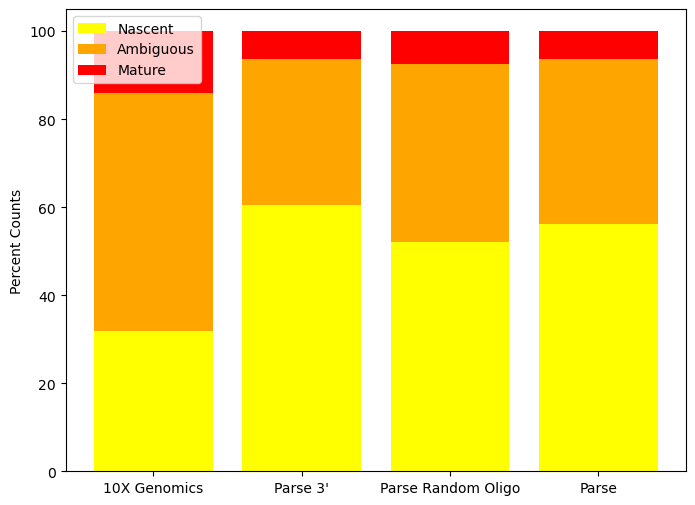

In [7]:
plotting.plot_nascent_mature_ratios(raw_datasets)

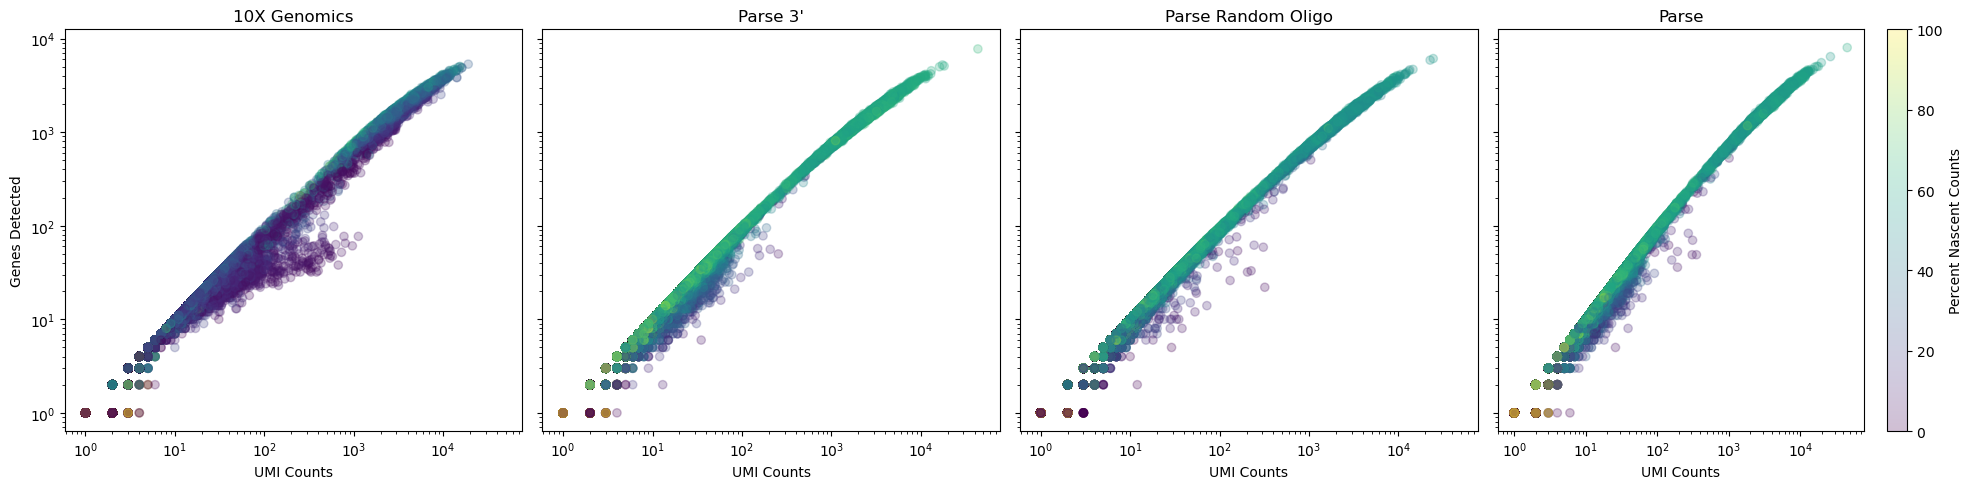

In [8]:
plotting.scatter_reads(raw_datasets)

In [9]:
gene_info = plotting.query_ensembl(PROJECT_DIR, index_dir=INDEX_DIR, species=SPECIES, overwrite=False)

In [10]:
for data in raw_datasets:
    plotting.add_cell_metrics(data, gene_info)

/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/functools.py:909: ImplicitModificationWarning: Transforming to str index.


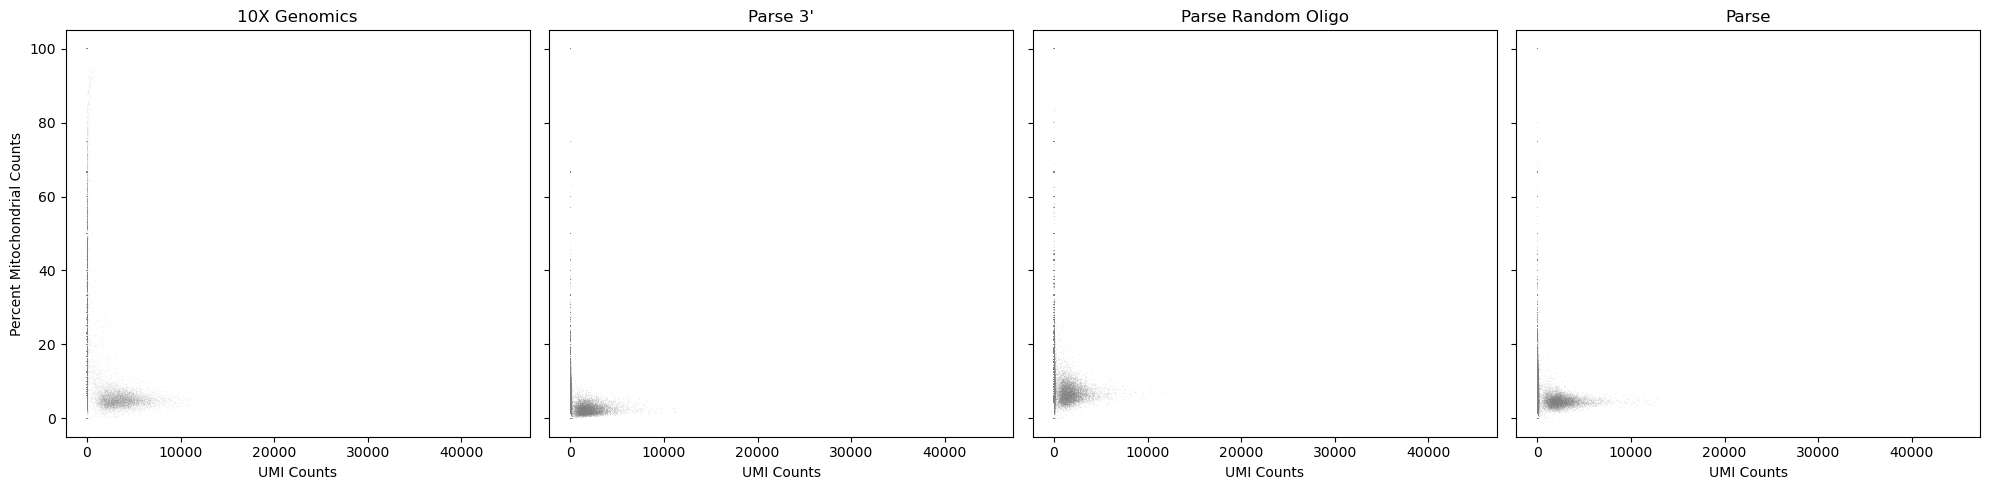

In [11]:
plotting.mito_scatter(raw_datasets)

8,441 cells passed the 300 UMI threshold for 10X Genomics
8,148 cells passed the 300 UMI threshold for Parse 3'
8,103 cells passed the 300 UMI threshold for Parse Random Oligo
8,202 cells passed the 300 UMI threshold for Parse


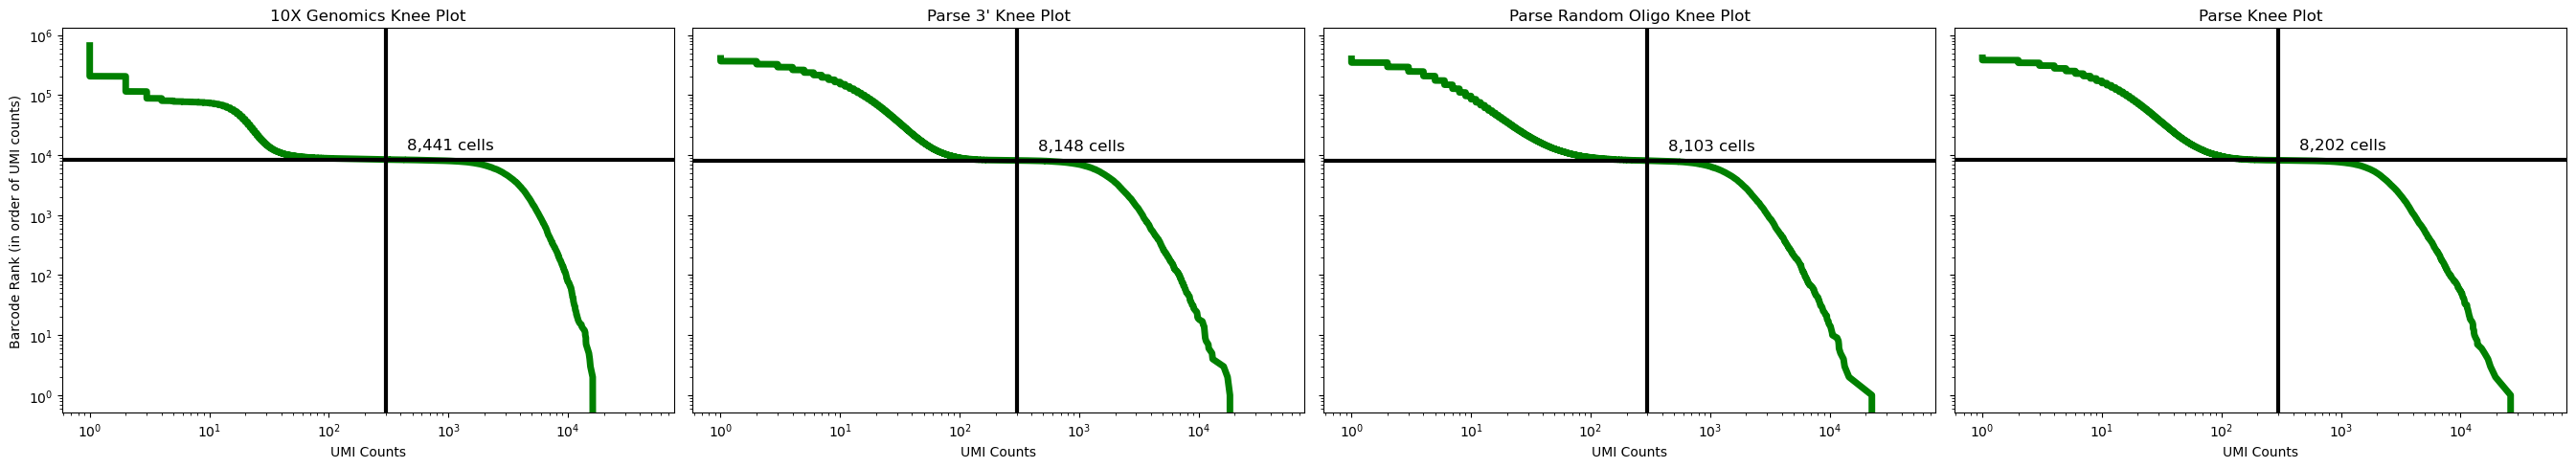

In [12]:
datasets = plotting.knee_plot(raw_datasets, cutoffs=CUTOFFS)

In [13]:
gene_info = plotting.update_gene_info(gene_info, datasets, FULL_GENE_INFO_PATH)

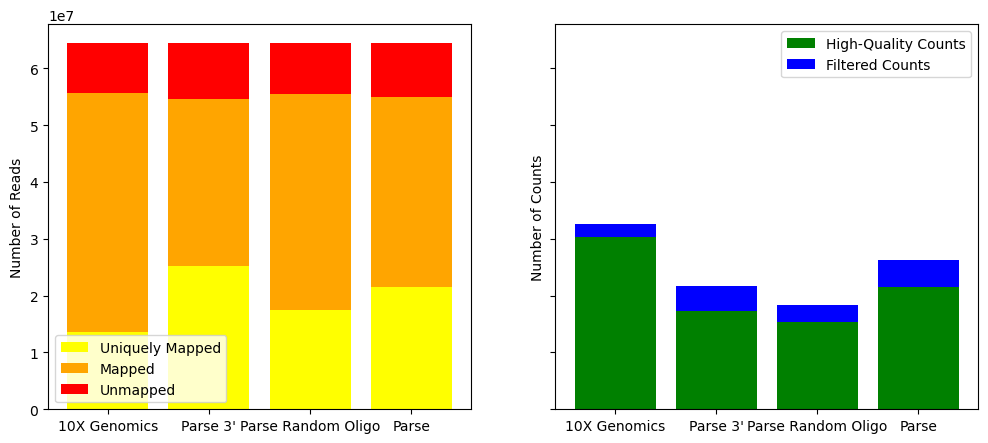

In [14]:
plotting.plot_filtering_metrics(datasets)

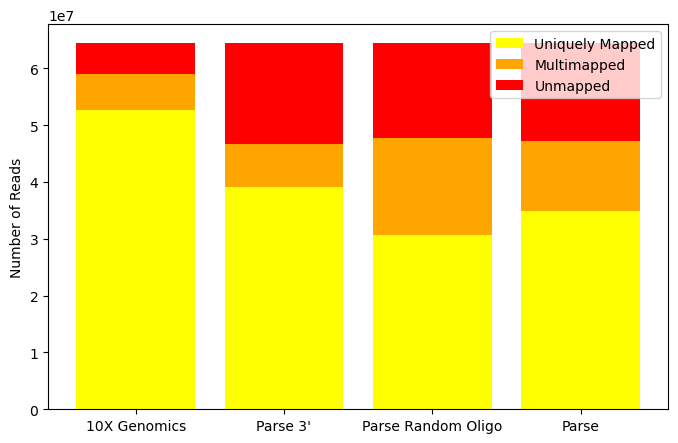

In [15]:
plotting.plot_filtering_metrics_star(datasets)

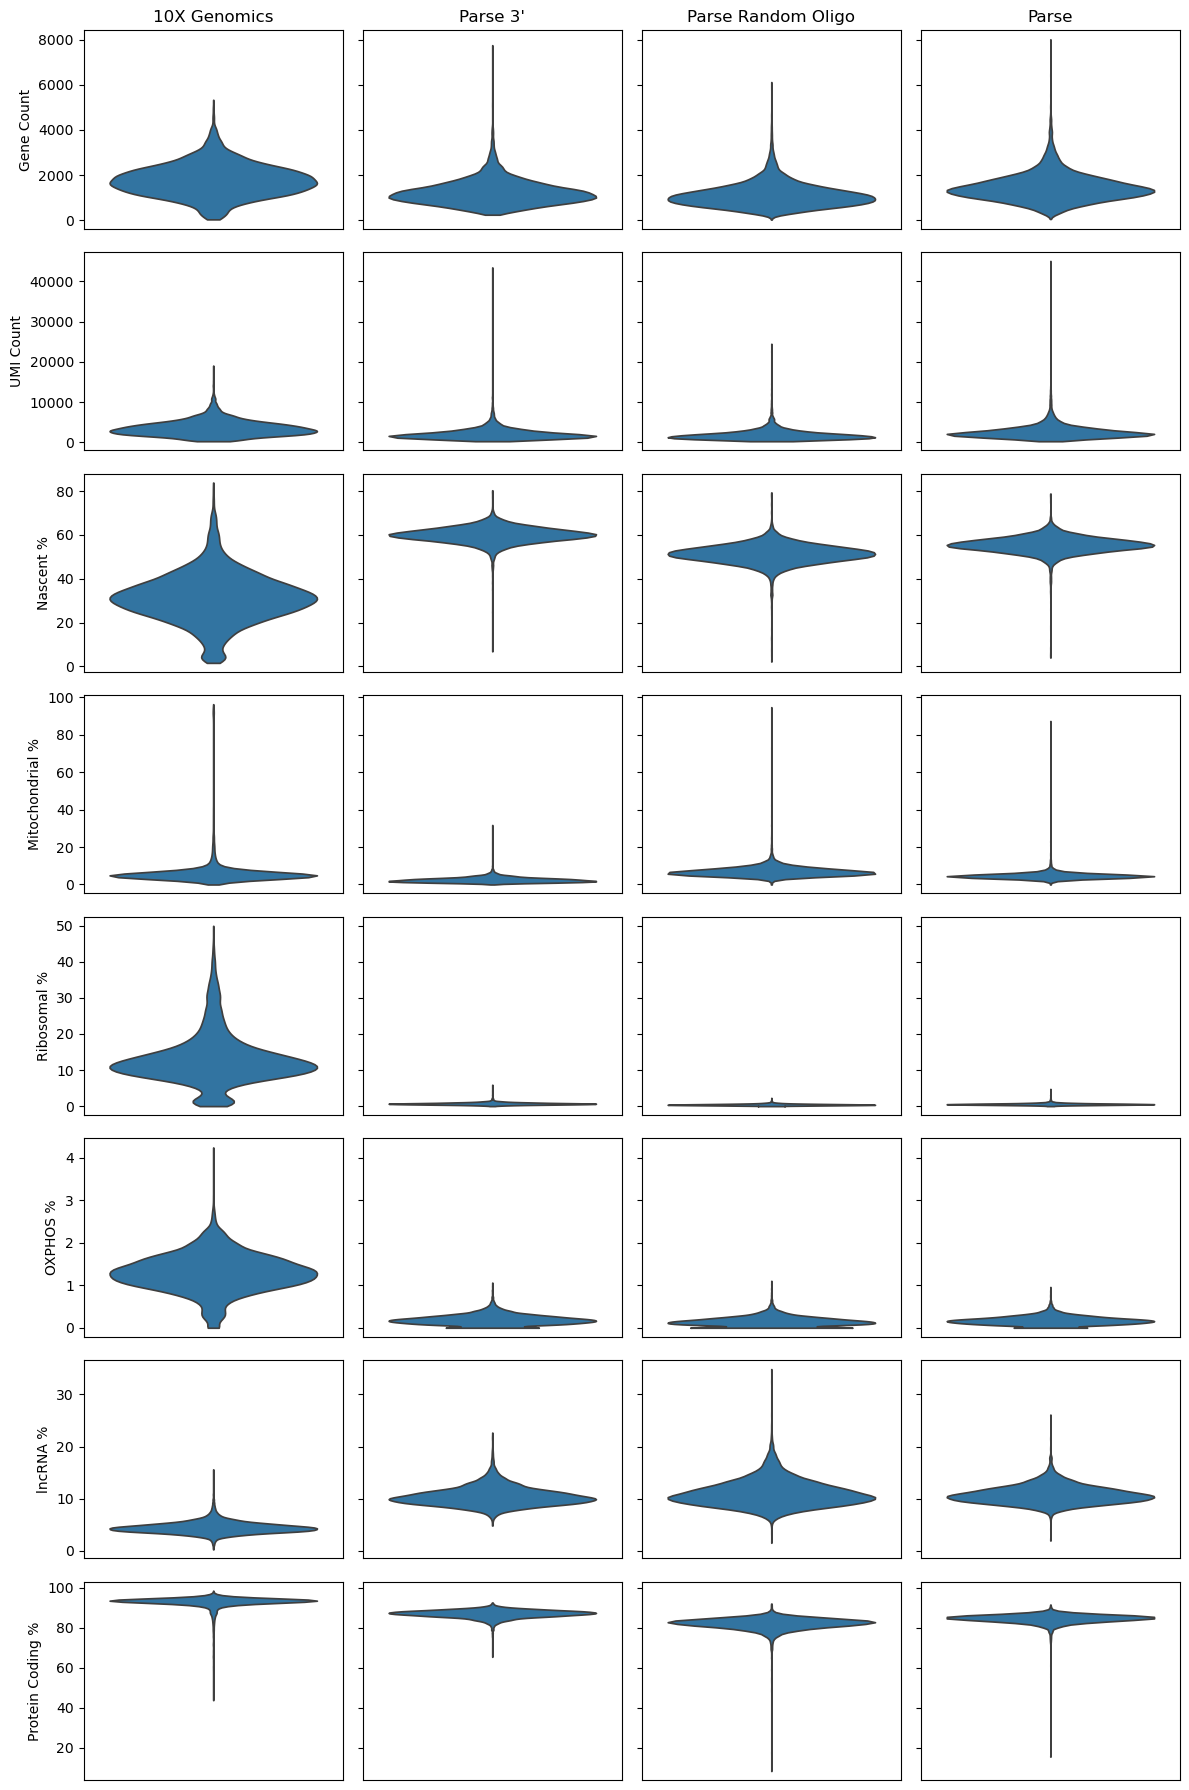

In [16]:
groups = ['n_genes', 'n_counts', 'percent_nascent', 'percent_mito', 'percent_ribo', 'percent_oxphos', 'percent_lnc', 'percent_pc']
group_names = ['Gene Count', 'UMI Count', 'Nascent %', 'Mitochondrial %', 'Ribosomal %', 'OXPHOS %', 'lncRNA %', 'Protein Coding %']

plotting.plot_cell_metrics(datasets, groups=groups, group_names=group_names)

# Read/Gene Comparisons

In [17]:
# Marker genes for PBMCs from www.biocompare.com
T_marker_names = ['CD3D', 'CD3G', 'CD3E', 'CD4', 'CD8A', 'CD8B']

B_marker_names = ['CD19', 'CD24', 'CD40', 'CD72']

NK_marker_names = ['FCGR3A', 'FCGR3B', 'NCAM1']

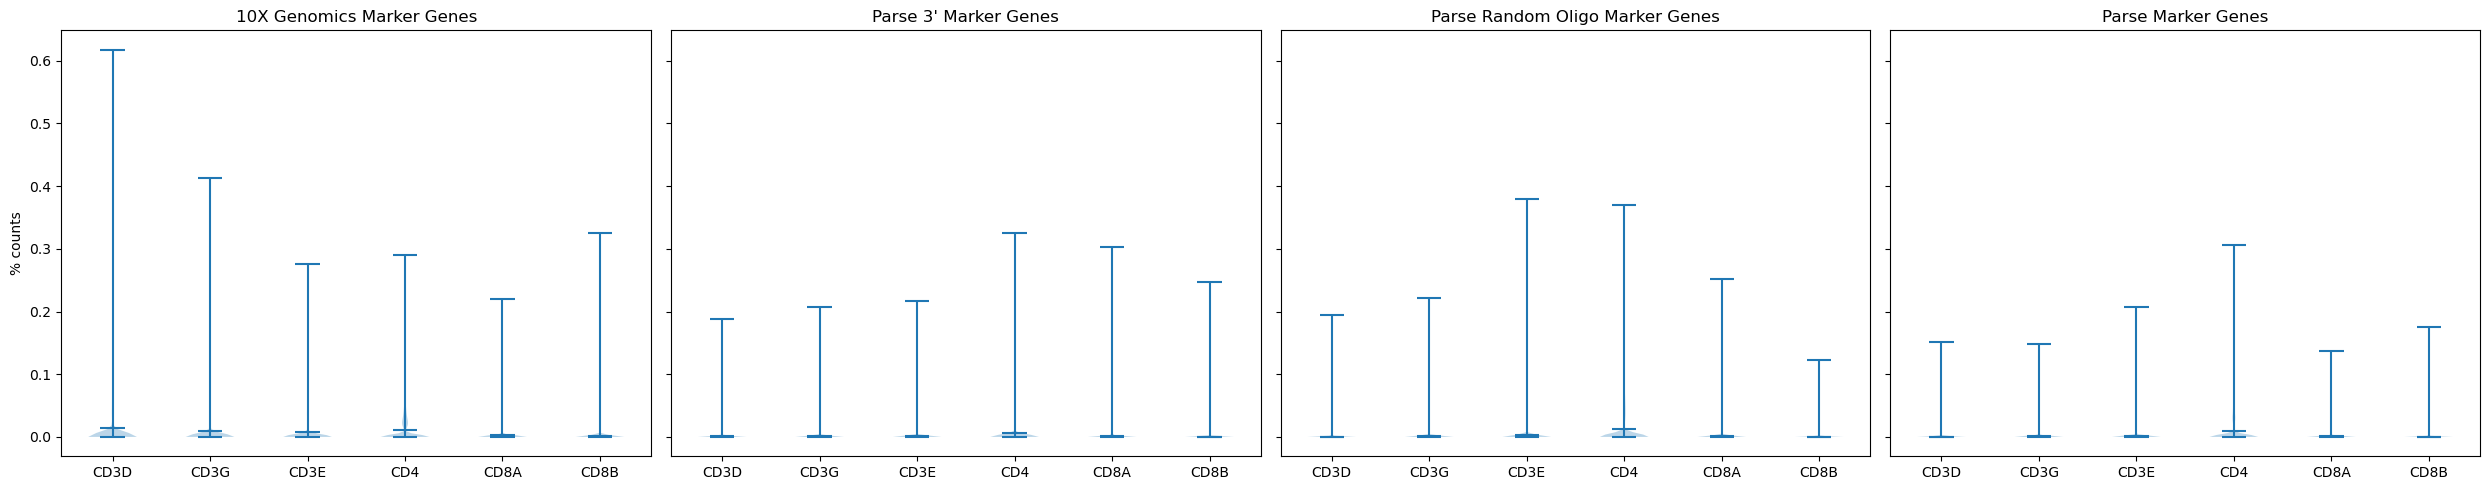

In [18]:
plotting.marker_genes(datasets, T_marker_names)

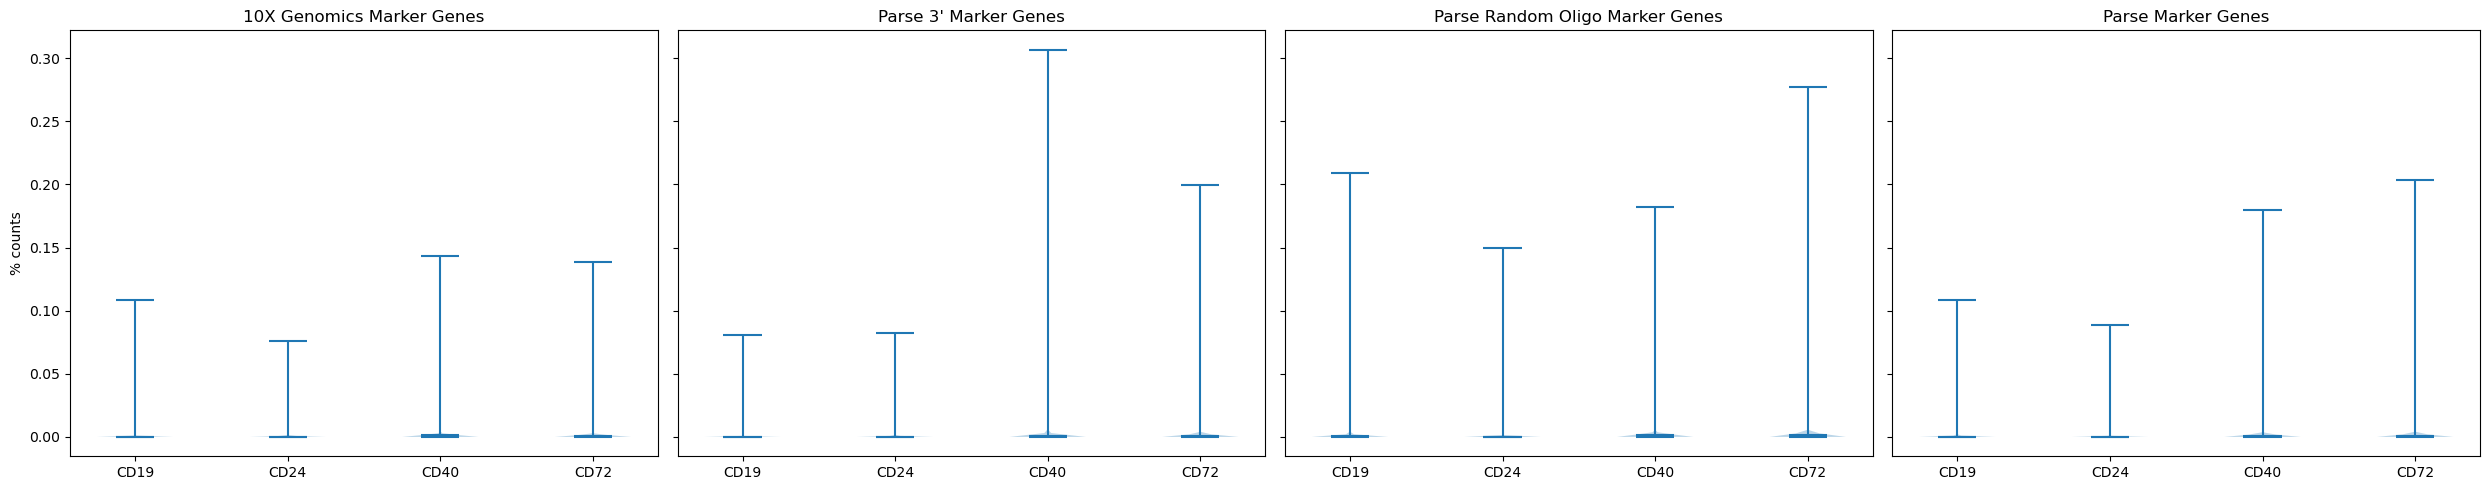

In [19]:
plotting.marker_genes(datasets, B_marker_names)

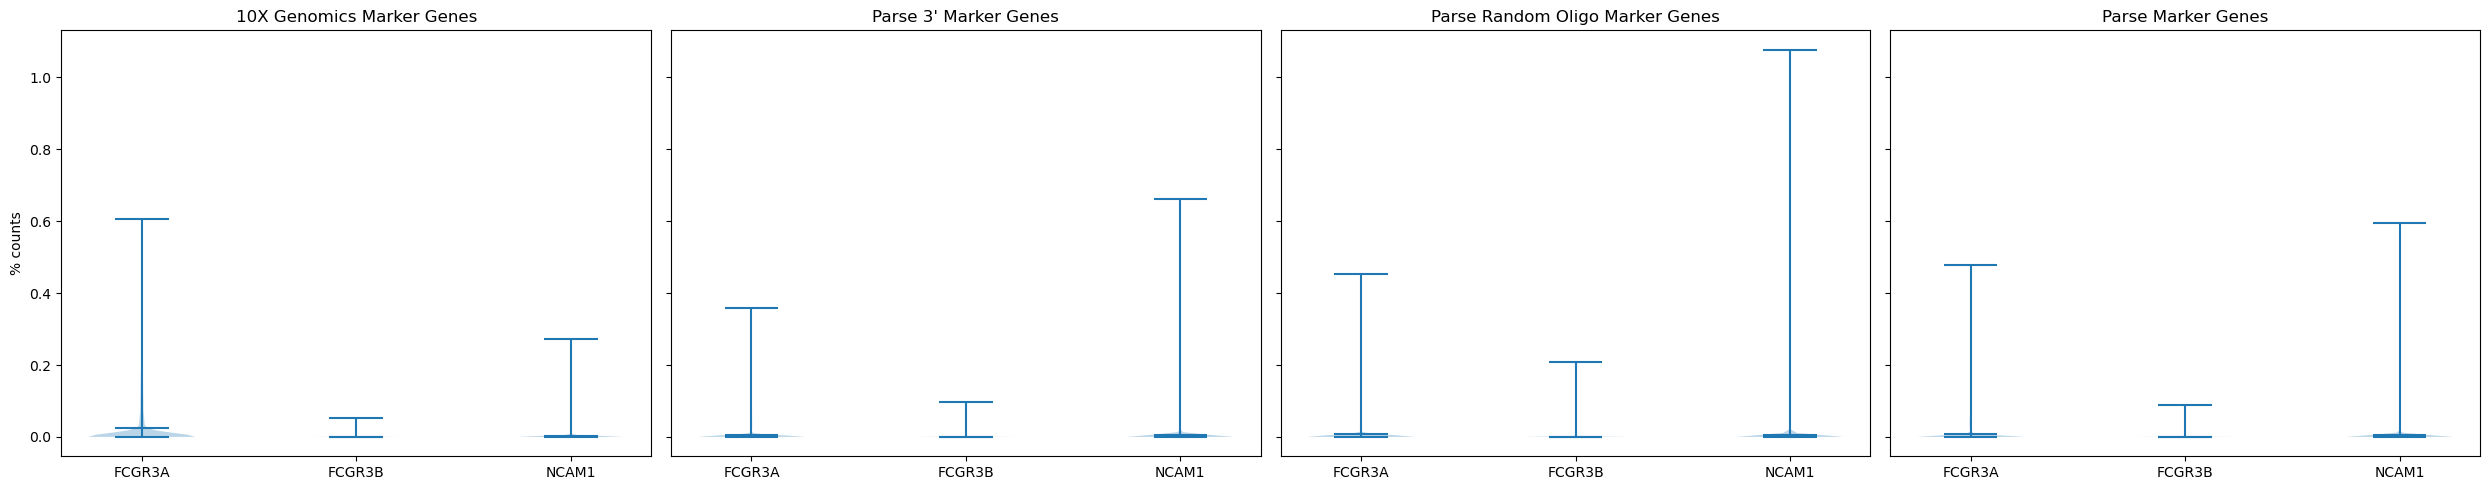

In [20]:
plotting.marker_genes(datasets, NK_marker_names)

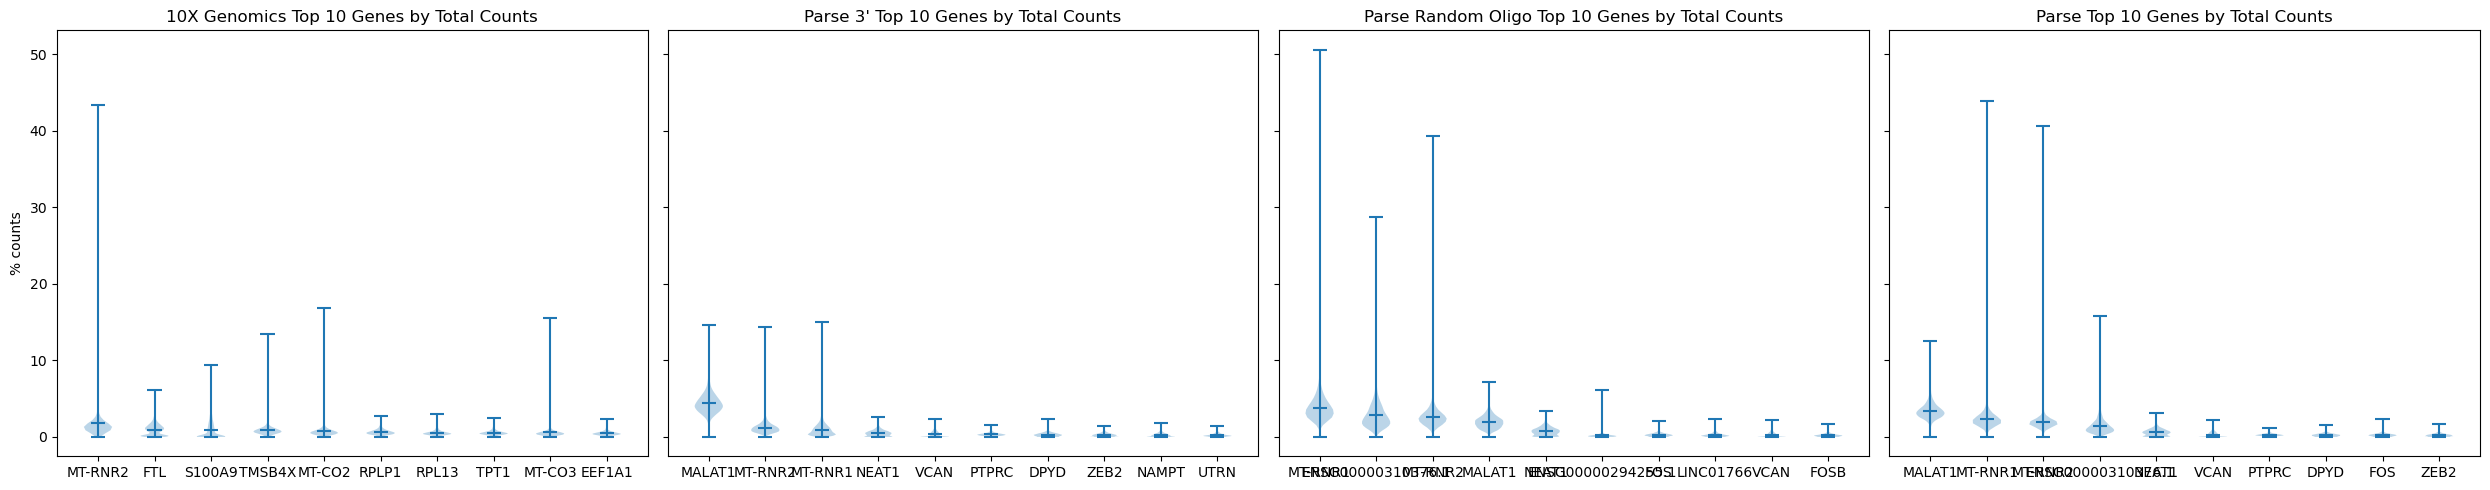

In [21]:
plotting.top_gene_counts(datasets)

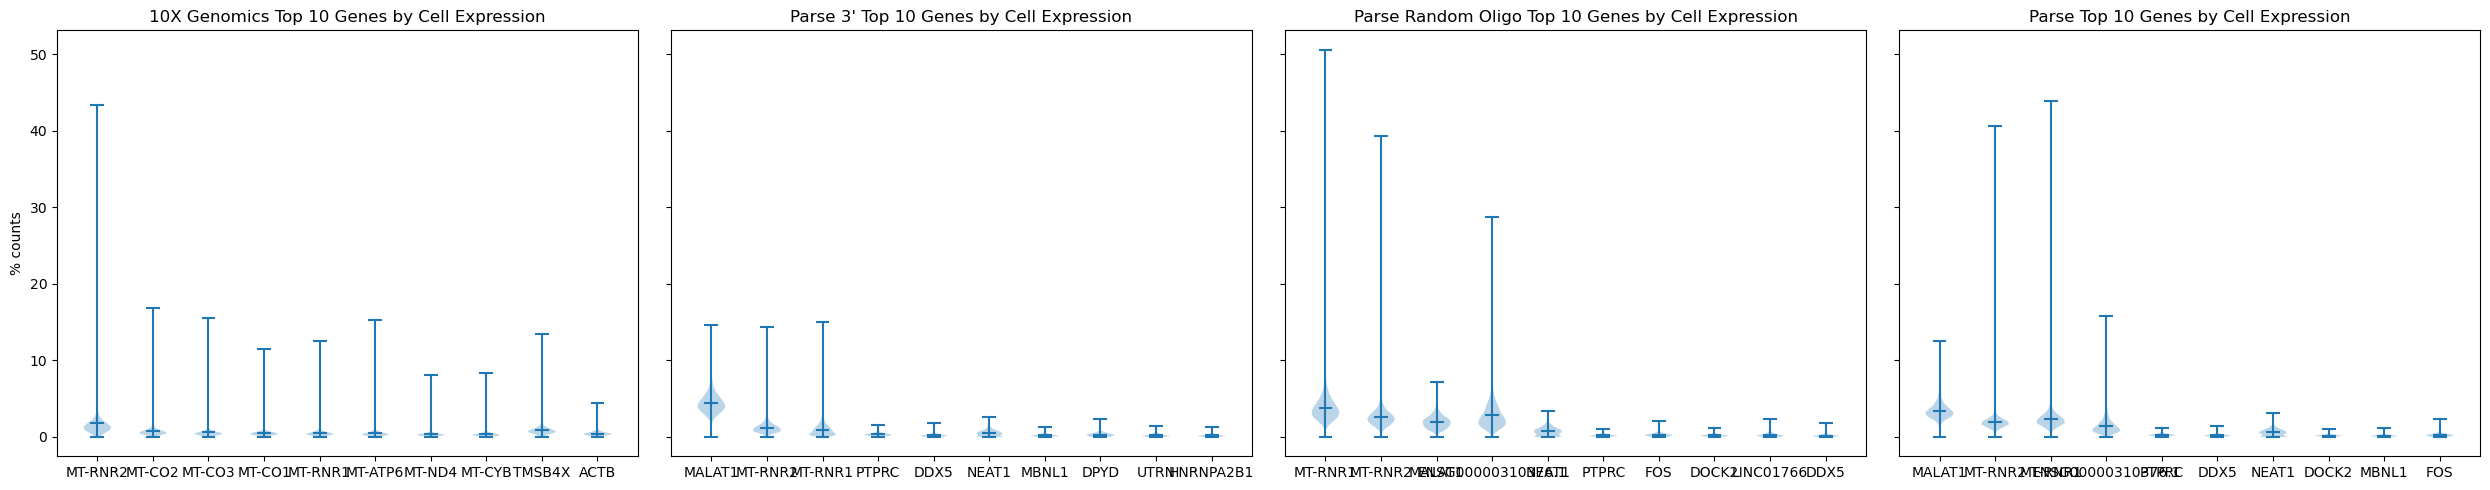

In [22]:
plotting.top_gene_cell_expression(datasets)

In [23]:
datasets[0]

AnnData object with n_obs × n_vars = 8442 × 39791
    obs: 'n_genes', 'n_counts', 'percent_nascent', 'percent_pc', 'percent_mito', 'percent_ribo', 'percent_lnc', 'percent_oxphos'
    var: 'gene_id', 'n_cells', 'percent_counts', 'percent_nascent', 'is_lnc', 'is_pc', 'is_mito', 'is_ribo', 'is_pseudo', 'is_oxphos', 'gene_length', 'gc_content', 'normalized_counts'
    uns: 'name', 'title', 'n_processed', 'n_aligned', 'n_unique', 'n_raw_counts', 'kb_PCBCOnlist', 'kb_PCReadsOnlist', 'star_uniquely_mapped', 'star_multimapped', 'star_unmapped', 'n_genes', 'percent_nascent', 'percent_ambiguous', 'percent_mature', 'pred_upsample', 'n_raw_counts_filtered'
    layers: 'ambiguous', 'mature', 'nascent'

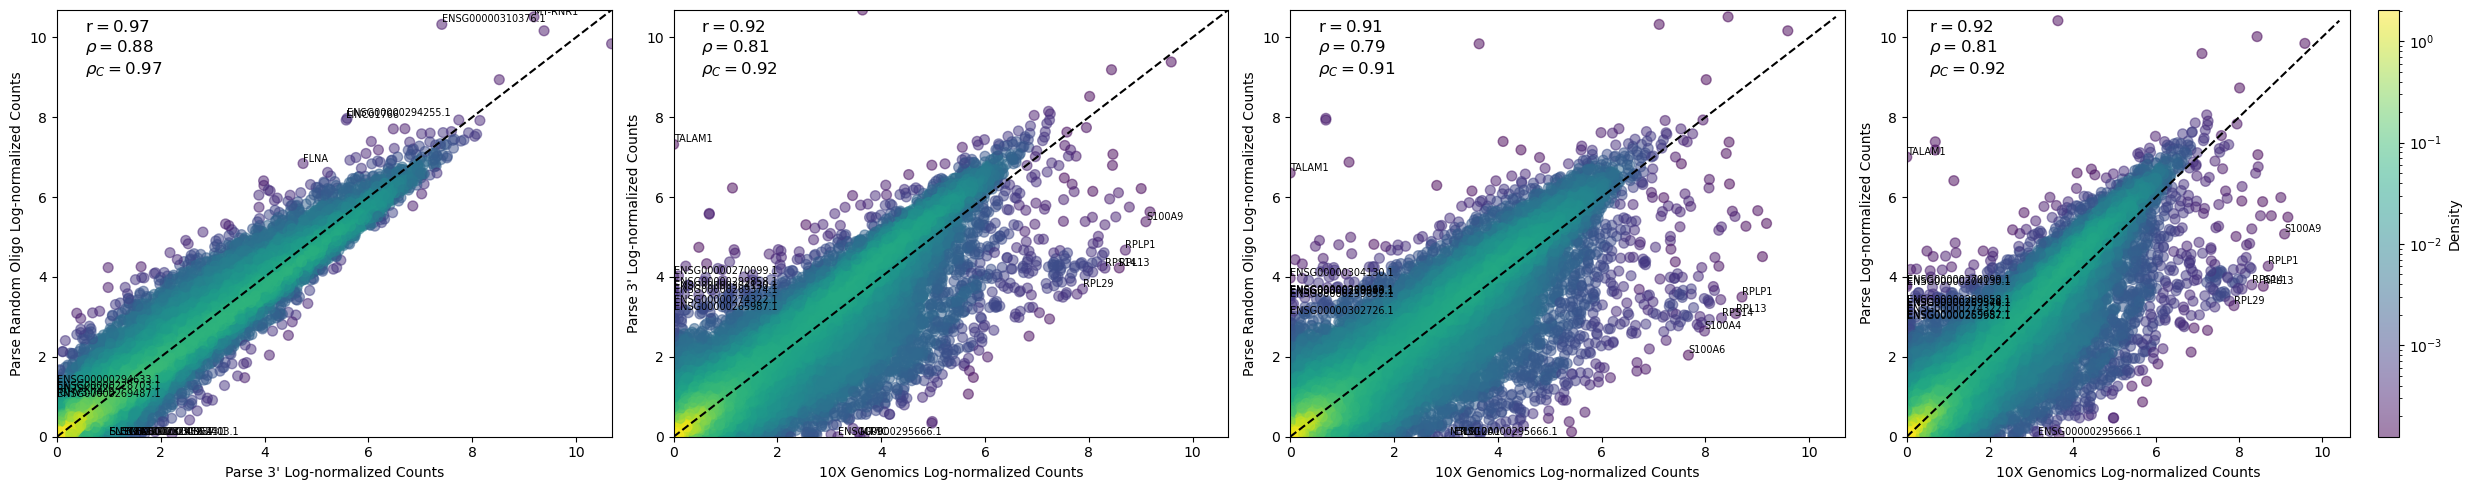

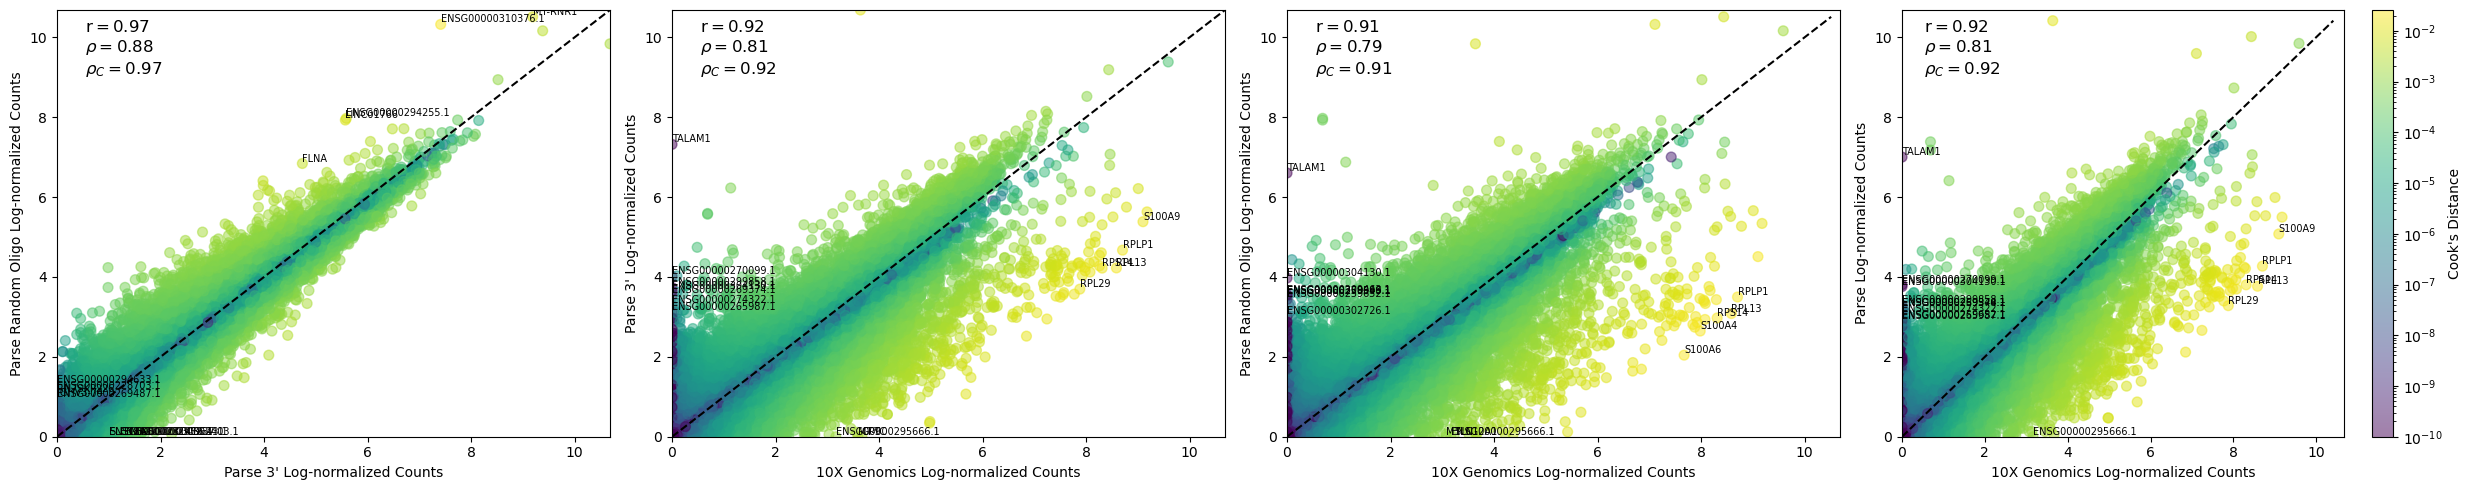

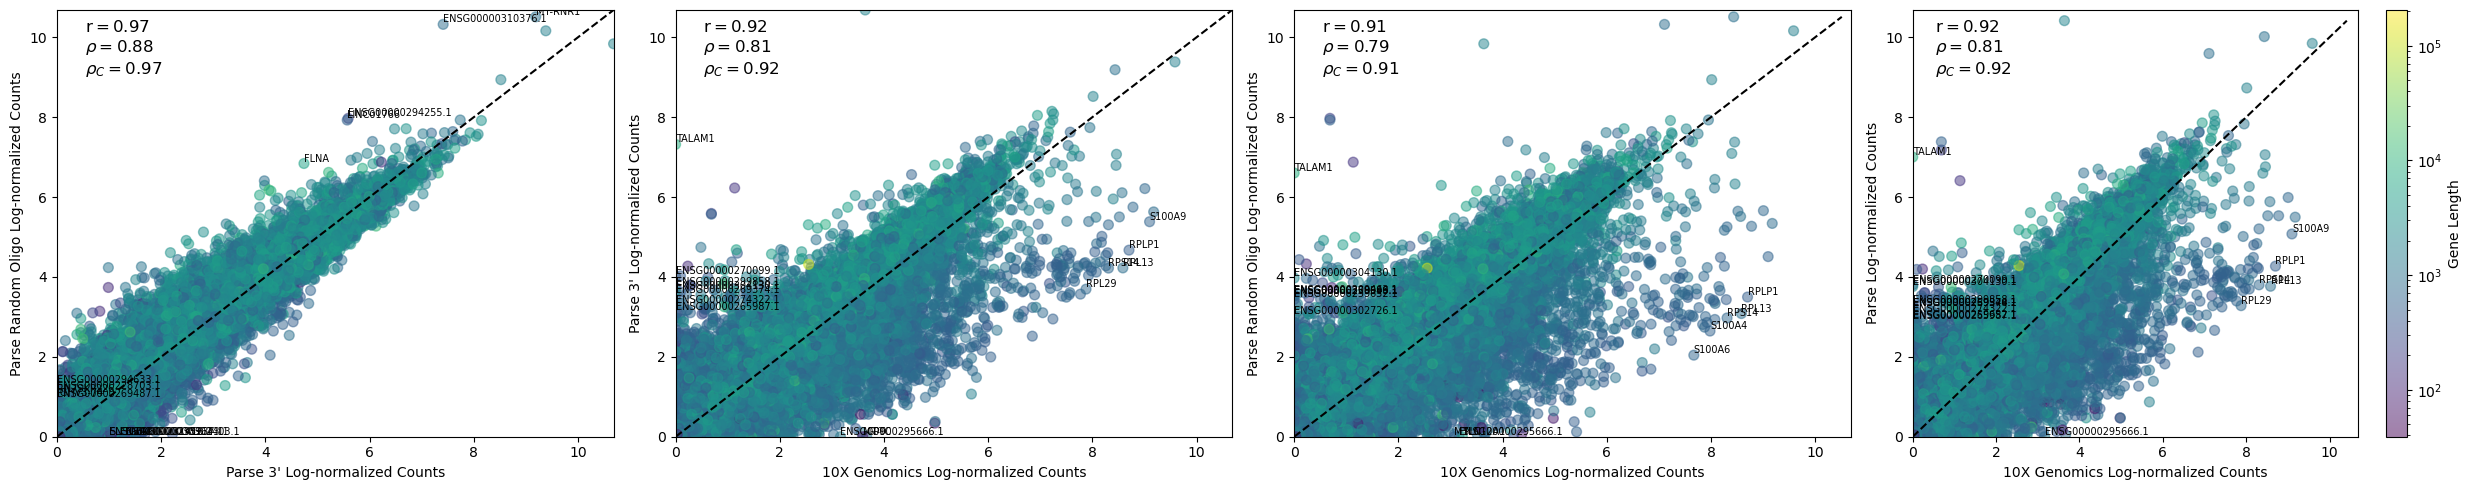

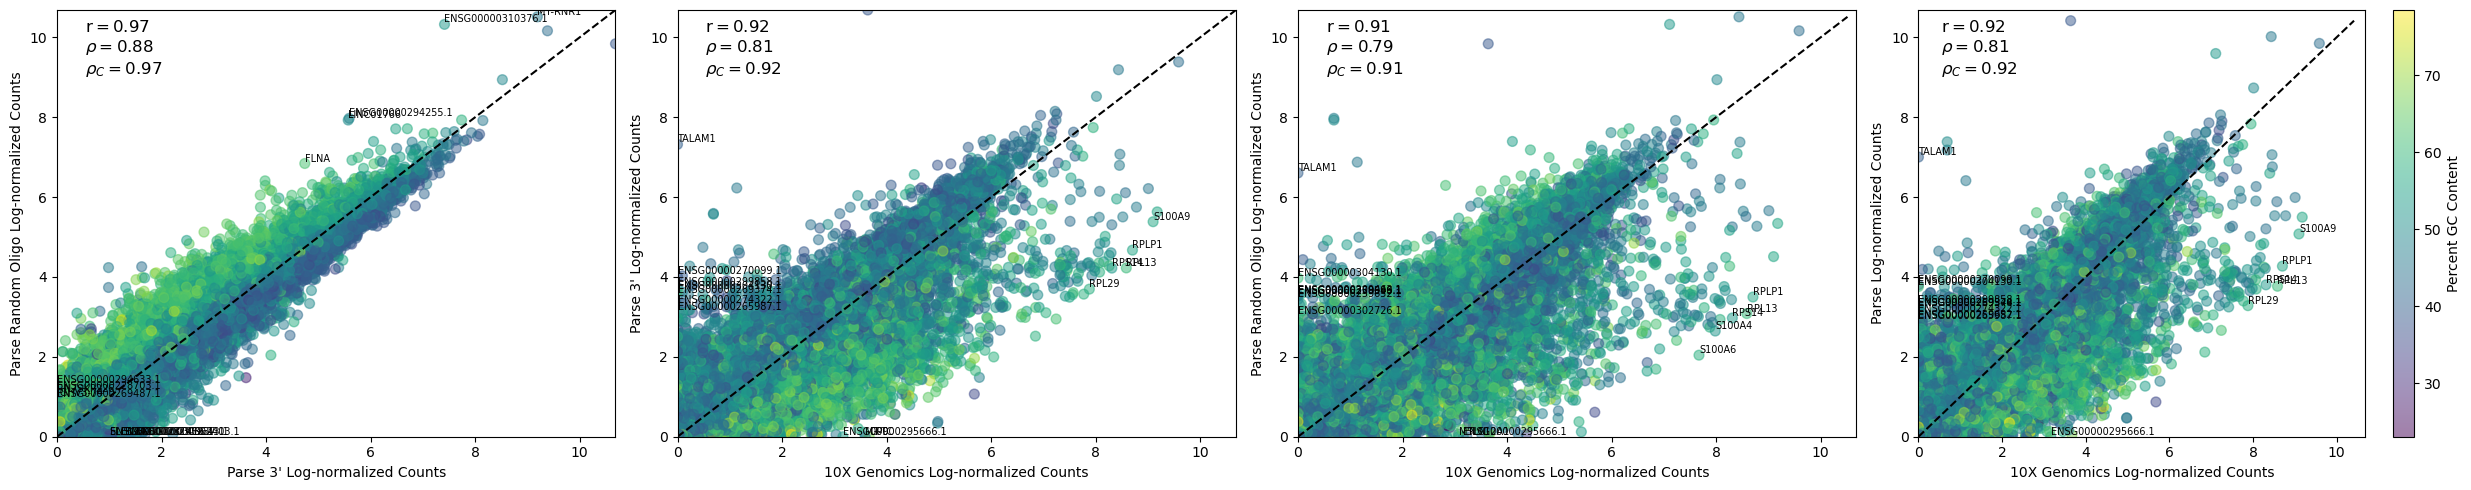

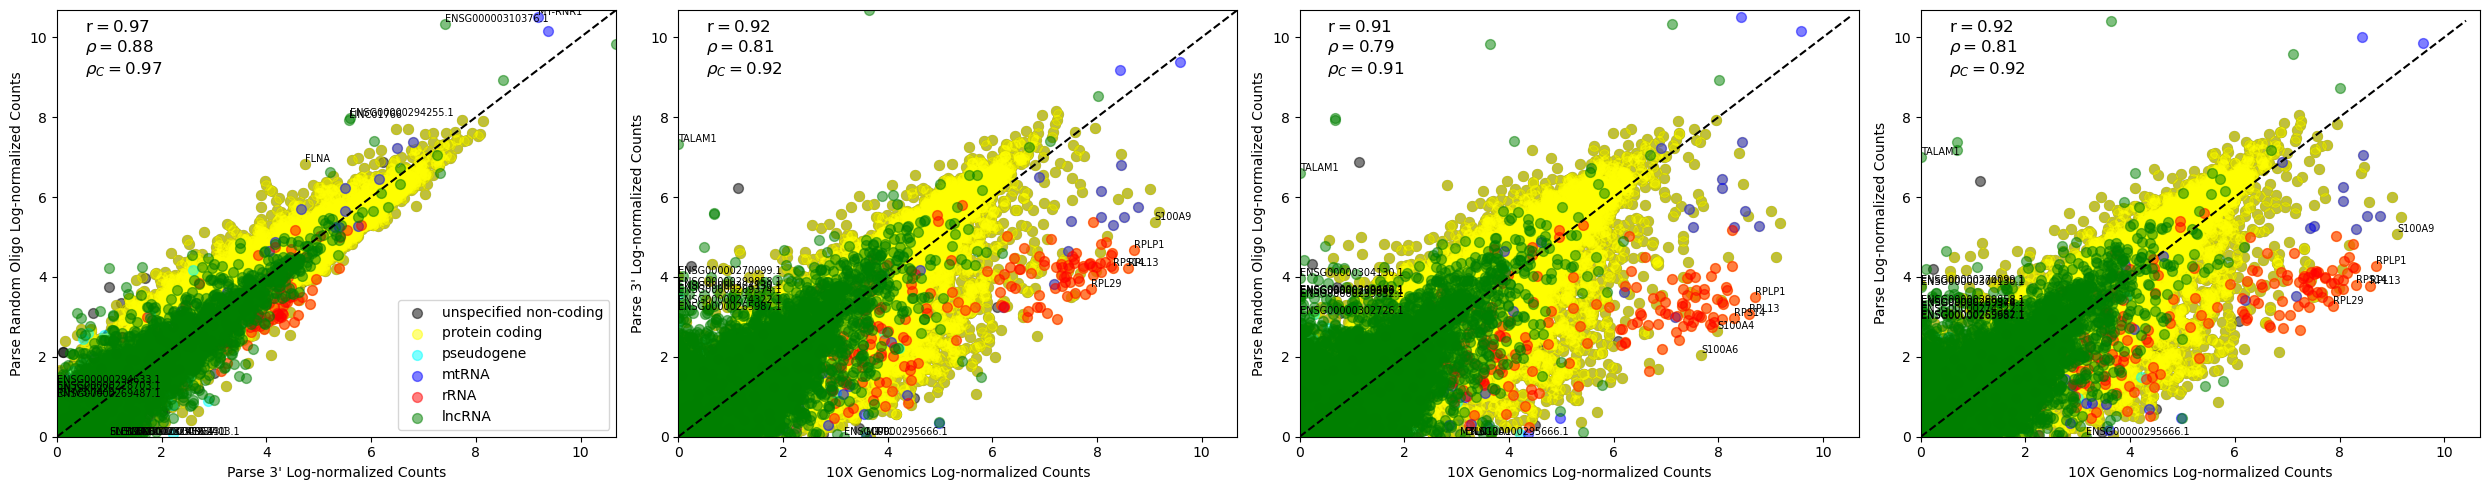

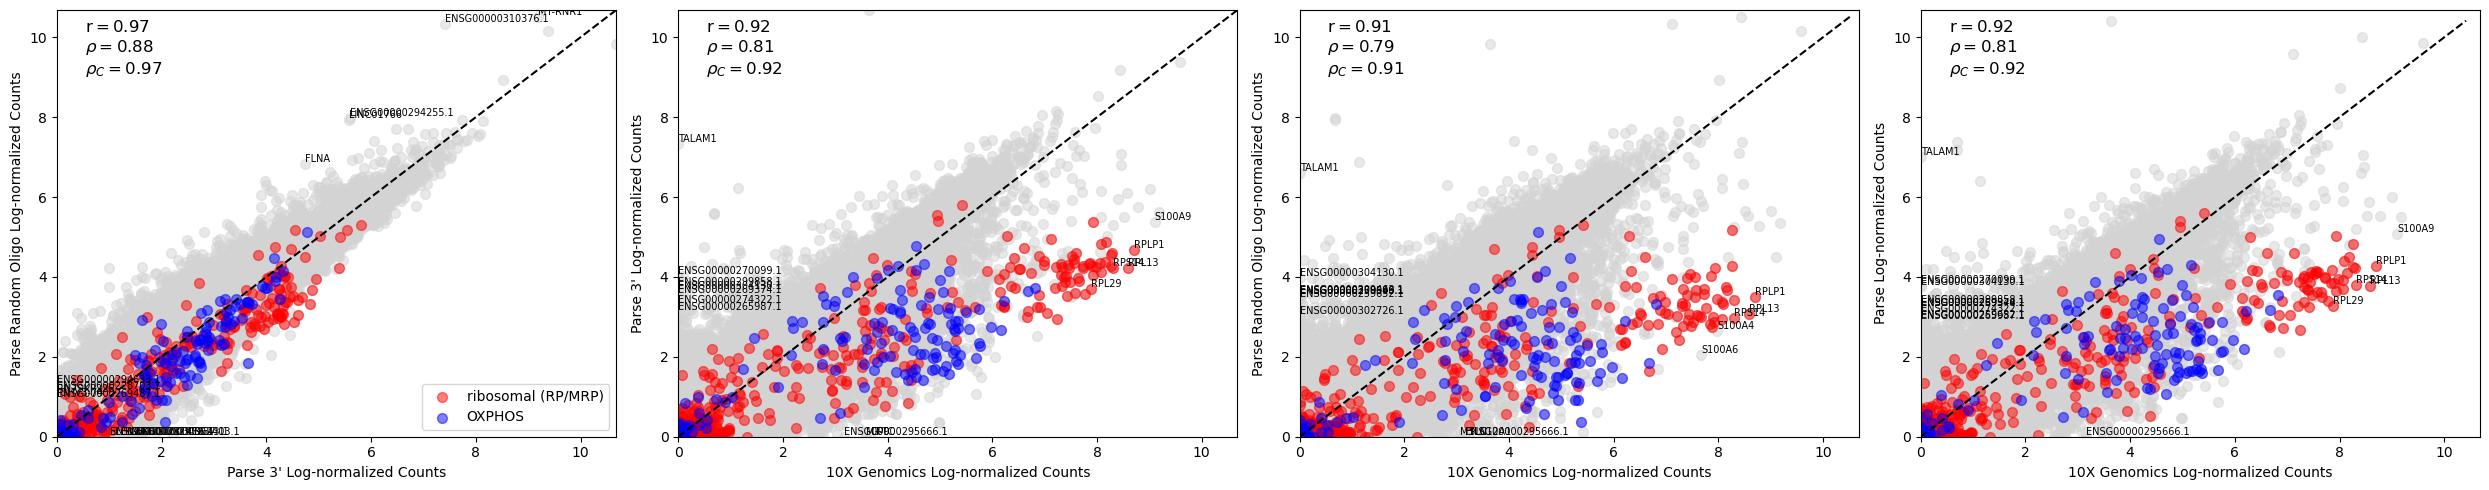

In [24]:
compare_names, compare_dfs = plotting.compare(datasets)


In [25]:
for name, df in zip(compare_names, compare_dfs):
    gene_info = plotting.merge_by_cooks(gene_info, name, df)
gene_info.to_csv(FULL_GENE_INFO_PATH)

## PBMC Clustering and Moncyte CD14+ extraction

In [26]:
import celltypist
from celltypist import models

In [27]:
models.download_models()

📂 Storing models in /home/mcaskey/.celltypist/data/models
⏩ Skipping [1/61]: Immune_All_Low.pkl (file exists)
⏩ Skipping [2/61]: Immune_All_High.pkl (file exists)
⏩ Skipping [3/61]: Adult_COVID19_PBMC.pkl (file exists)


⏩ Skipping [4/61]: Adult_CynomolgusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [5/61]: Adult_Human_MTG.pkl (file exists)
⏩ Skipping [6/61]: Adult_Human_PancreaticIslet.pkl (file exists)
⏩ Skipping [7/61]: Adult_Human_PrefrontalCortex.pkl (file exists)
⏩ Skipping [8/61]: Adult_Human_Skin.pkl (file exists)
⏩ Skipping [9/61]: Adult_Human_Vascular.pkl (file exists)
⏩ Skipping [10/61]: Adult_Mouse_Gut.pkl (file exists)
⏩ Skipping [11/61]: Adult_Mouse_OlfactoryBulb.pkl (file exists)
⏩ Skipping [12/61]: Adult_Pig_Hippocampus.pkl (file exists)
⏩ Skipping [13/61]: Adult_RhesusMacaque_Hippocampus.pkl (file exists)
⏩ Skipping [14/61]: Adult_cHSPCs_Illumina.pkl (file exists)
⏩ Skipping [15/61]: Adult_cHSPCs_Ultima.pkl (file exists)
⏩ Skipping [16/61]: Autopsy_COVID19_Lung.pkl (file exists)
⏩ Skipping [17/61]: COVID19_HumanChallenge_Blood.pkl (file exists)
⏩ Skipping [18/61]: COVID19_Immune_Landscape.pkl (file exists)
⏩ Skipping [19/61]: Cells_Adult_Breast.pkl (file exists)
⏩ Skipping [20/61]:

In [28]:
model = models.Model.load(model='Immune_All_High.pkl')

In [29]:
labelled_datasets = []
for data in datasets:
    sc.pp.normalize_total(data, target_sum=1e4)
    sc.pp.log1p(data)
    labelled_datasets.append(celltypist.annotate(data, model=model, majority_voting=True).to_adata())


🔬 Input data has 8442 cells and 39791 genes
🔗 Matching reference genes in the model
🧬 5556 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
/home/mcaskey/.conda/envs/10XvParse/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the predictions
✅ Majority voting done!
🔬 Input data has 8149 cells and 39044 genes
🔗 Matching reference genes in the model
🧬 5368 features used for prediction
⚖️ Scaling input data
🖋️ Predicting labels
✅ Prediction done!
👀 Can not detect a neighborhood graph, will construct one before the over-clustering
⛓️ Over-clustering input data with resolution set to 10
🗳️ Majority voting the pr

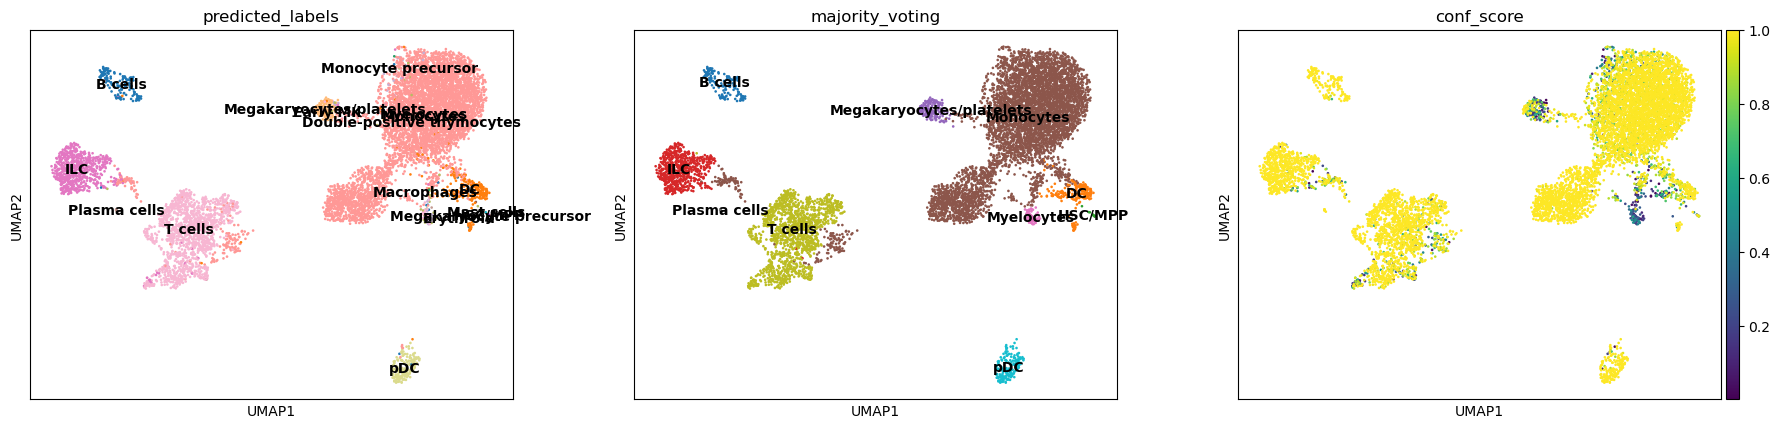

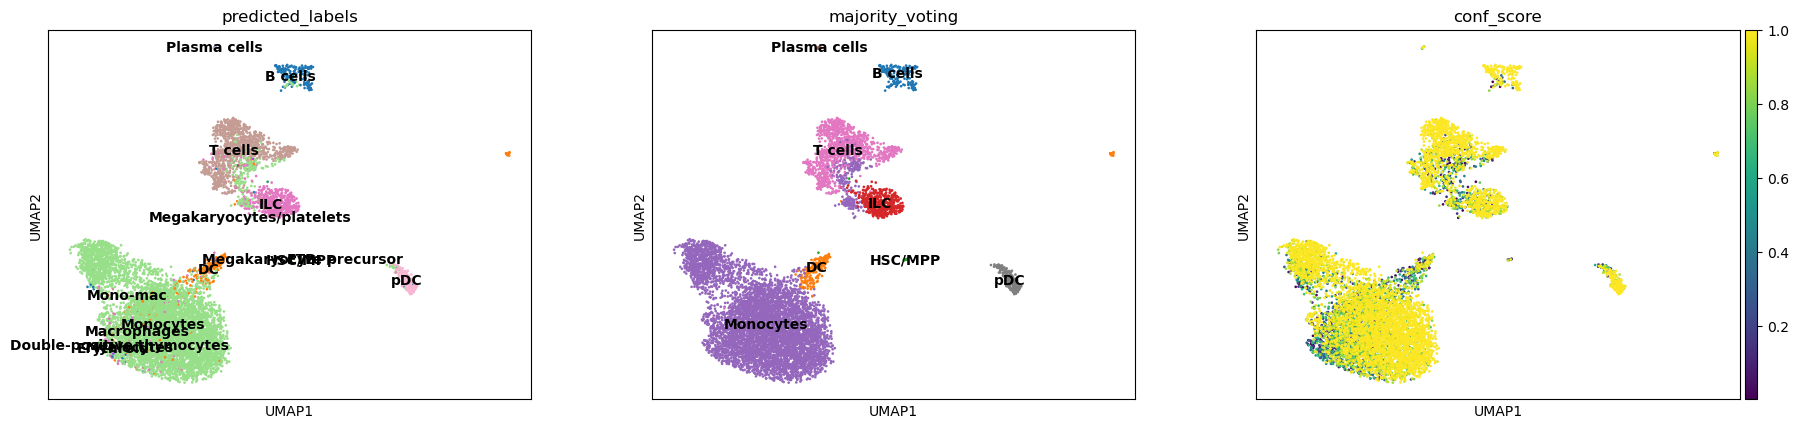

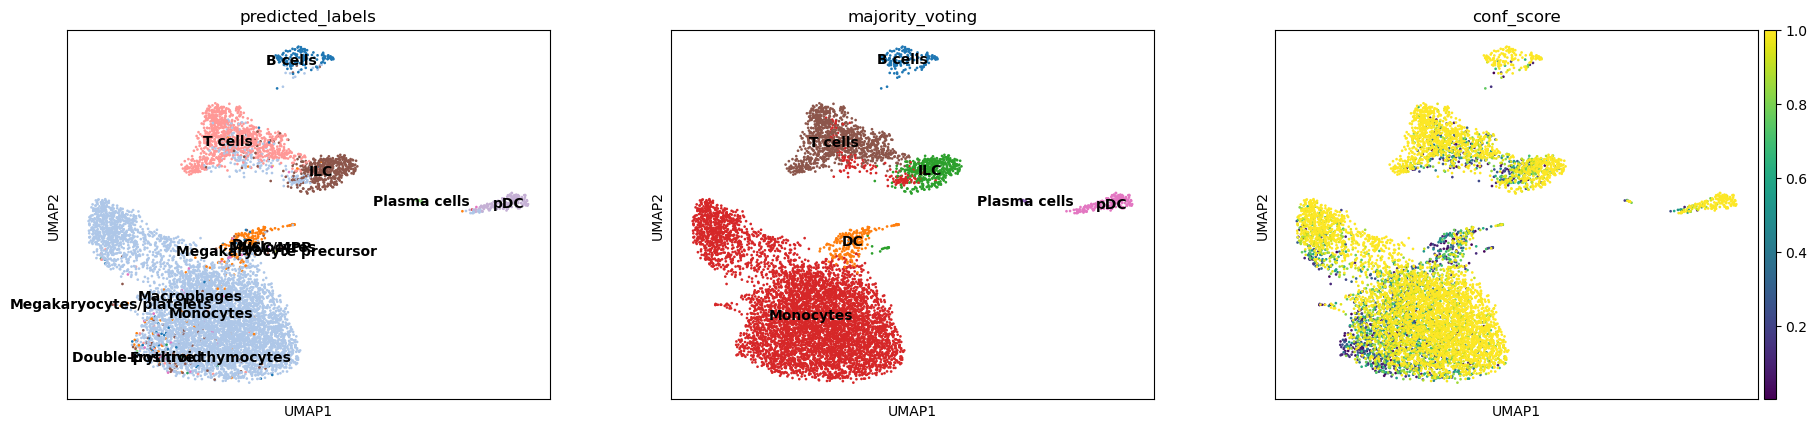

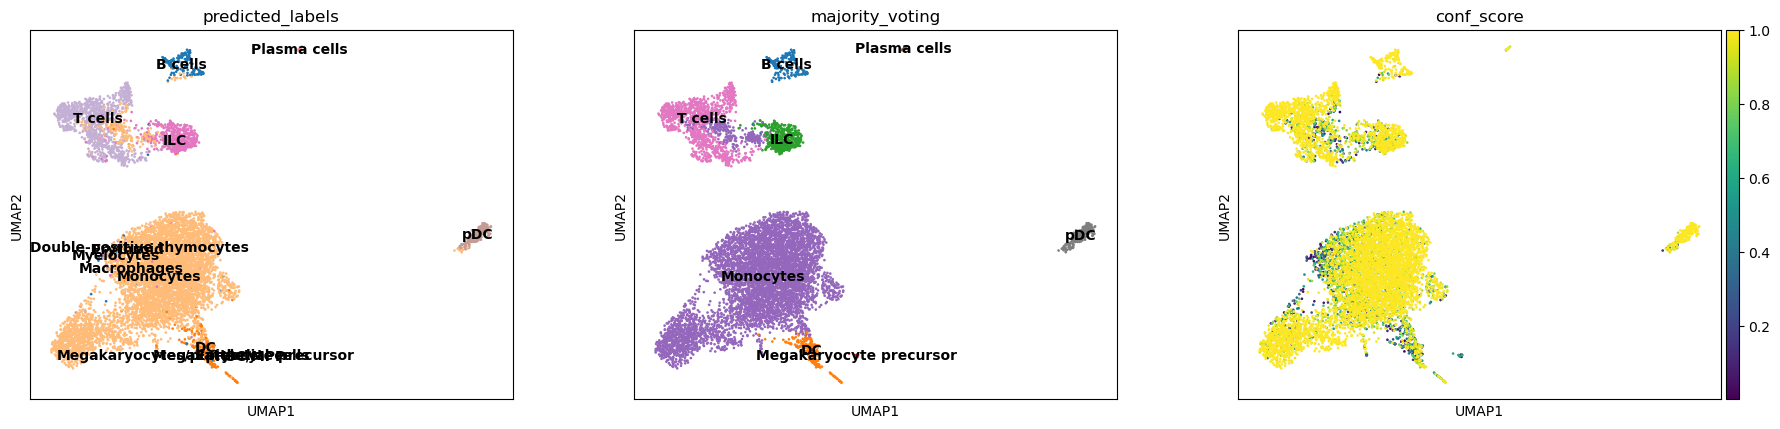

In [30]:
for data in labelled_datasets:
    sc.tl.umap(data)
    sc.pl.umap(data, color = ['predicted_labels', 'majority_voting', 'conf_score'], legend_loc='on data')

{'T cells': [0.16512674721629947, 0.13154988342127868, 0.13919052319842054, 0.1308058027550896], 'Monocytes': [0.6656005685856432, 0.7393545220272426, 0.7333415597235933, 0.7453370718029989], 'ILC': [0.07569296375266525, 0.05693950177935943, 0.05824284304047384, 0.05437035231013044], 'B cells': [0.018952854773750295, 0.0198797398453798, 0.01961994076999013, 0.019870778983298792], 'pDC': [0.020848140251125327, 0.022579457602159774, 0.022458045409674235, 0.022430817993417042], 'DC': [0.023335702440180052, 0.026506319793839734, 0.02566633761105627, 0.02425941728635865], 'Other': [0.030443022980336413, 0.003190575530739968, 0.0014807502467917078, 0.0029257588687065707]}


<Figure size 640x480 with 0 Axes>

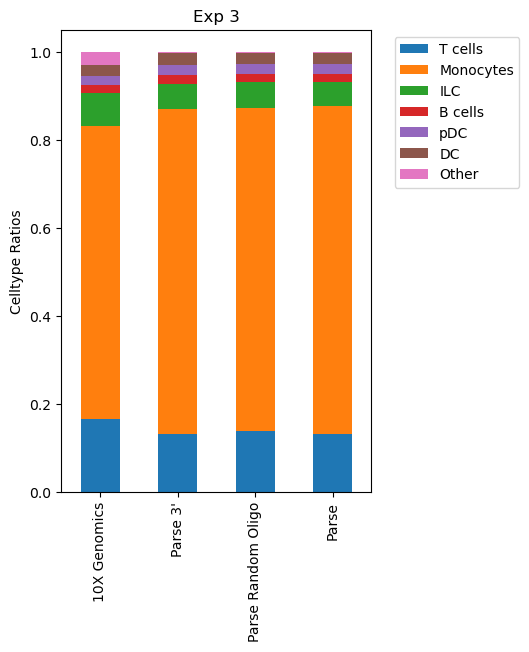

In [37]:
celltype_labels = ['T cells', 'Monocytes', 'ILC',  'B cells', 'pDC', 'DC', 'Other']
celltype_props = {label: [(data.obs['majority_voting'] == label).sum() / len(data.obs) for data in labelled_datasets] for label in celltype_labels[:-1]}
celltype_props['Other'] = [(~data.obs['majority_voting'].isin(celltype_labels[:-1])).sum() / len(data.obs) for data in labelled_datasets]
celltype_props_df = pd.DataFrame(celltype_props, index=[data.uns['title'] for data in labelled_datasets])

plt.figure()
ax = celltype_props_df.plot(kind='bar', stacked=True, figsize=(4, 6))
ax.legend(bbox_to_anchor=(1.5, 1), loc='upper right')
plt.title('Exp 3')
plt.ylabel('Celltype Ratios')

print(celltype_props)

In [39]:
[(data.obs['majority_voting'] == 'Megakaryocytes/platelets').sum()/len(data.obs) for data in labelled_datasets]

[0.020966595593461264, 0.0, 0.0, 0.0]